In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Upload the data:

#df = pd.read_csv('Downloads/NYPD_Arrest_Data__Year_to_Date__20250909.csv')
#df = pd.read_csv('Cleaned_nypd_arrest_data.csv')
df = pd.read_csv('NYPD_Arrests_Data__Historic__20250918.csv')

In [3]:
#Display the data:

df.head()

,ARREST_KEY,ARREST_DATE,PD_DESC,KY_CD,OFNS_DESC,ARREST_BORO,AGE_GROUP,PERP_SEX,PERP_RACE,Latitude,Longitude
0,298702124,12/31/2024,"CONTROLLED SUBSTANCE, POSSESSI",235.0,DANGEROUS DRUGS,K,25-44,M,BLACK,40.687872,-73.933032
1,298699274,12/31/2024,"ASSAULT 2,1,UNCLASSIFIED",106.0,FELONY ASSAULT,M,25-44,F,BLACK,40.813056,-73.949068
2,298679856,12/31/2024,"ASSAULT 2,1,UNCLASSIFIED",106.0,FELONY ASSAULT,B,25-44,F,WHITE HISPANIC,40.816067,-73.917644
3,298694773,12/31/2024,CRIMINAL MIS 2 & 3,121.0,CRIMINAL MISCHIEF & RELATED OF,B,25-44,M,BLACK,40.822534,-73.906096
4,298703584,12/31/2024,"CRIMINAL MISCHIEF,UNCLASSIFIED 4",351.0,CRIMINAL MISCHIEF & RELATED OF,M,25-44,M,WHITE HISPANIC,40.751978,-73.989915


In [4]:
df = df.rename(columns={
    'Latitude': 'LATITUDE',
    'Longitude': 'LONGITUDE'
})

print(df.shape)
print(df.columns)
df.tail()

(2375018, 11)
Index(['ARREST_KEY', 'ARREST_DATE', 'PD_DESC', 'KY_CD', 'OFNS_DESC',
       'ARREST_BORO', 'AGE_GROUP', 'PERP_SEX', 'PERP_RACE', 'LATITUDE',
       'LONGITUDE'],
      dtype='object')


,ARREST_KEY,ARREST_DATE,PD_DESC,KY_CD,OFNS_DESC,ARREST_BORO,AGE_GROUP,PERP_SEX,PERP_RACE,LATITUDE,LONGITUDE
2375013,140394446,01/01/2015,"ROBBERY,UNCLASSIFIED,OPEN AREAS",105.0,ROBBERY,M,18-24,M,BLACK,40.842022,-73.936298
2375014,140394419,01/01/2015,"MENACING,UNCLASSIFIED",344.0,ASSAULT 3 & RELATED OFFENSES,K,25-44,M,BLACK,40.684742,-73.930918
2375015,140394488,01/01/2015,ASSAULT 3,344.0,ASSAULT 3 & RELATED OFFENSES,Q,45-64,M,WHITE HISPANIC,40.769941,-73.920450
2375016,140392533,01/01/2015,"SEXUAL ABUSE 3,2",233.0,FORCIBLE TOUCHING,B,25-44,M,UNKNOWN,40.816392,-73.895296
2375017,140389298,01/01/2015,ASSAULT 3,344.0,ASSAULT 3 & RELATED OFFENSES,B,25-44,F,BLACK,40.817992,-73.886439


In [5]:
df.describe()

,ARREST_KEY,KY_CD,LATITUDE,LONGITUDE
count,2.375018e+06,2.370467e+06,2.375014e+06,2.375014e+06
mean,2.032629e+08,2.677859e+02,4.073830e+01,-7.392370e+01
std,5.006316e+07,1.559925e+02,1.197129e-01,1.763310e-01
min,1.403814e+08,1.010000e+02,0.000000e+00,-7.425494e+01
25%,1.576327e+08,1.170000e+02,4.067732e+01,-7.397487e+01
50%,1.917172e+08,3.410000e+02,4.073584e+01,-7.392593e+01
75%,2.465130e+08,3.440000e+02,4.081411e+01,-7.388151e+01
max,2.987485e+08,9.950000e+02,4.091296e+01,0.000000e+00


In [6]:
#Drop null values:

print("Number of null values per column:")
print(df.isnull().sum())

Number of null values per column:
ARREST_KEY        0
ARREST_DATE       0
PD_DESC        3932
KY_CD          4551
OFNS_DESC      3932
ARREST_BORO       0
AGE_GROUP         0
PERP_SEX          0
PERP_RACE         0
LATITUDE          4
LONGITUDE         4
dtype: int64


In [7]:
print("\nRows with null values:")
rows_with_null = df[df.isnull().any(axis=1)]
display(rows_with_null)


Rows with null values:


,ARREST_KEY,ARREST_DATE,PD_DESC,KY_CD,OFNS_DESC,ARREST_BORO,AGE_GROUP,PERP_SEX,PERP_RACE,LATITUDE,LONGITUDE
2280,298572175,12/28/2024,OBSTR BREATH/CIRCUL,344.0,ASSAULT 3 & RELATED OFFENSES,Q,18-24,M,BLACK,NaN,NaN
2778,298548914,12/27/2024,"TRAFFIC,UNCLASSIFIED MISDEMEAN",348.0,VEHICLE AND TRAFFIC LAWS,Q,18-24,M,BLACK,NaN,NaN
3448,298499931,12/26/2024,"TRAFFIC,UNCLASSIFIED MISDEMEAN",348.0,VEHICLE AND TRAFFIC LAWS,Q,25-44,M,BLACK,NaN,NaN
3449,298494808,12/26/2024,"TRAFFIC,UNCLASSIFIED MISDEMEAN",348.0,VEHICLE AND TRAFFIC LAWS,Q,25-44,F,UNKNOWN,NaN,NaN
14140,297743412,12/09/2024,(null),NaN,(null),M,25-44,M,WHITE HISPANIC,40.716337,-74.001251
...,...,...,...,...,...,...,...,...,...,...,...
2371616,140473389,01/08/2015,NaN,NaN,NaN,M,25-44,M,BLACK,40.807775,-73.945470
2372373,140459006,01/07/2015,NaN,NaN,NaN,B,25-44,M,WHITE HISPANIC,40.816089,-73.917689
2374388,140400705,01/02/2015,NaN,NaN,NaN,B,25-44,M,BLACK HISPANIC,40.822298,-73.911694
2374597,140403375,01/02/2015,NaN,NaN,NaN,M,18-24,M,BLACK,40.758207,-73.976398


In [8]:
df = df.dropna()
df = df.drop_duplicates()

In [9]:
columns_to_drop = ['KY_CD']
df = df.drop(columns=columns_to_drop)
display(df.head())

,ARREST_KEY,ARREST_DATE,PD_DESC,OFNS_DESC,ARREST_BORO,AGE_GROUP,PERP_SEX,PERP_RACE,LATITUDE,LONGITUDE
0,298702124,12/31/2024,"CONTROLLED SUBSTANCE, POSSESSI",DANGEROUS DRUGS,K,25-44,M,BLACK,40.687872,-73.933032
1,298699274,12/31/2024,"ASSAULT 2,1,UNCLASSIFIED",FELONY ASSAULT,M,25-44,F,BLACK,40.813056,-73.949068
2,298679856,12/31/2024,"ASSAULT 2,1,UNCLASSIFIED",FELONY ASSAULT,B,25-44,F,WHITE HISPANIC,40.816067,-73.917644
3,298694773,12/31/2024,CRIMINAL MIS 2 & 3,CRIMINAL MISCHIEF & RELATED OF,B,25-44,M,BLACK,40.822534,-73.906096
4,298703584,12/31/2024,"CRIMINAL MISCHIEF,UNCLASSIFIED 4",CRIMINAL MISCHIEF & RELATED OF,M,25-44,M,WHITE HISPANIC,40.751978,-73.989915


In [10]:
print(df.index)
print(df.index.is_unique)
print(df.index.is_monotonic_increasing)
df.reset_index(drop=True)
print(df.shape)

Index([      0,       1,       2,       3,       4,       5,       6,       7,
             8,       9,
       ...
       2375008, 2375009, 2375010, 2375011, 2375012, 2375013, 2375014, 2375015,
       2375016, 2375017],
      dtype='int64', length=2370463)
True
True
(2370463, 10)


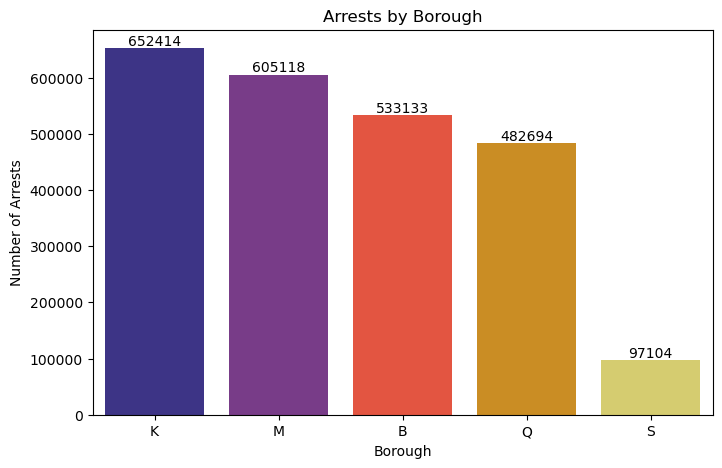

In [11]:
borough_counts = df['ARREST_BORO'].value_counts()

top_offenses = df['OFNS_DESC'].value_counts().head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=borough_counts.index, y=borough_counts.values, palette="CMRmap", hue=borough_counts.index, legend=False)
plt.title("Arrests by Borough")
plt.xlabel("Borough")
plt.ylabel("Number of Arrests")
for index, value in enumerate(borough_counts.values):
    plt.text(index, value, str(value), ha='center', va='bottom')
plt.show()

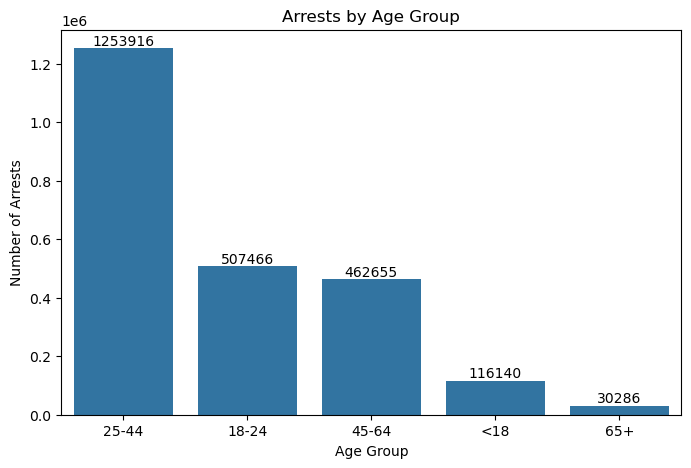

In [12]:
### Arrests by Age Group:

age_group_counts = df['AGE_GROUP'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=age_group_counts.index, y=age_group_counts.values, legend=False)
plt.title("Arrests by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Arrests")
for index, value in enumerate(age_group_counts.values):
    plt.text(index, value, str(value), ha='center', va='bottom')
plt.show()

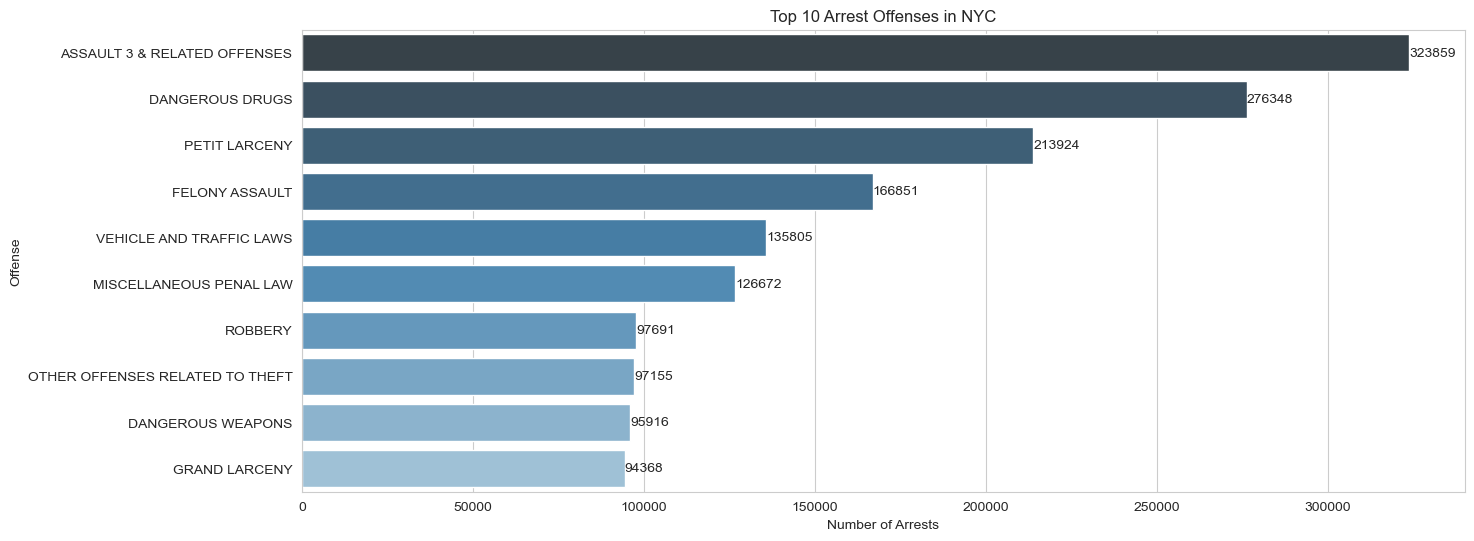

In [23]:
plt.figure(figsize=(15,6))
sns.barplot(y=top_offenses.index, x=top_offenses.values,palette="Blues_r_d", hue=top_offenses.index, legend=False)
plt.title("Top 10 Arrest Offenses in NYC")
plt.xlabel("Number of Arrests")
plt.ylabel("Offense")
for index, value in enumerate(top_offenses.values):
    plt.text(value, index, str(value), va='center')
plt.show()

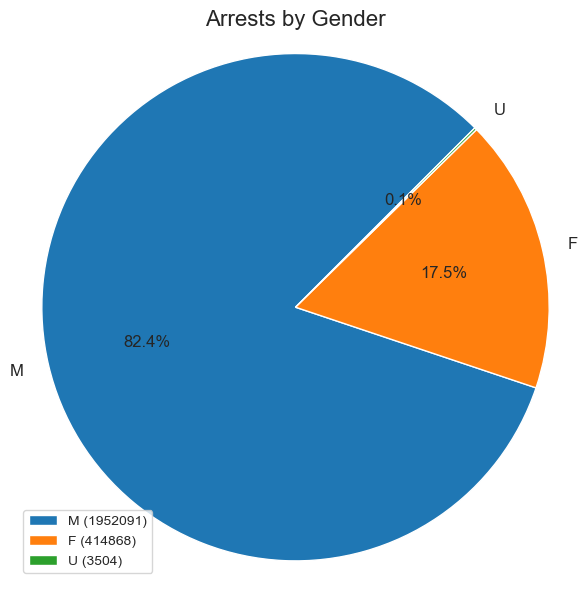

In [29]:
# Get gender counts
gender_counts = df['PERP_SEX'].value_counts()

plt.figure(figsize=(6, 6))

# Create the pie chart
plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=45,
    shadow=False,
    textprops={'fontsize': 12}
)

# Add title and ensure it's a circle
plt.title("Arrests by Gender", fontsize=16)
plt.axis('equal')

# Add a legend with absolute values
plt.legend(
    [f"{label} ({value})" for label, value in zip(gender_counts.index, gender_counts.values)],
    loc="best"
)

plt.tight_layout()
plt.show()

In [15]:
df['ARREST_DATE'] = pd.to_datetime(df['ARREST_DATE'])
df['ARREST_MONTH'] = df['ARREST_DATE'].dt.month
df['ARREST_DAY'] = df['ARREST_DATE'].dt.day
df['ARREST_WEEKDAY'] = df['ARREST_DATE'].dt.day_name()

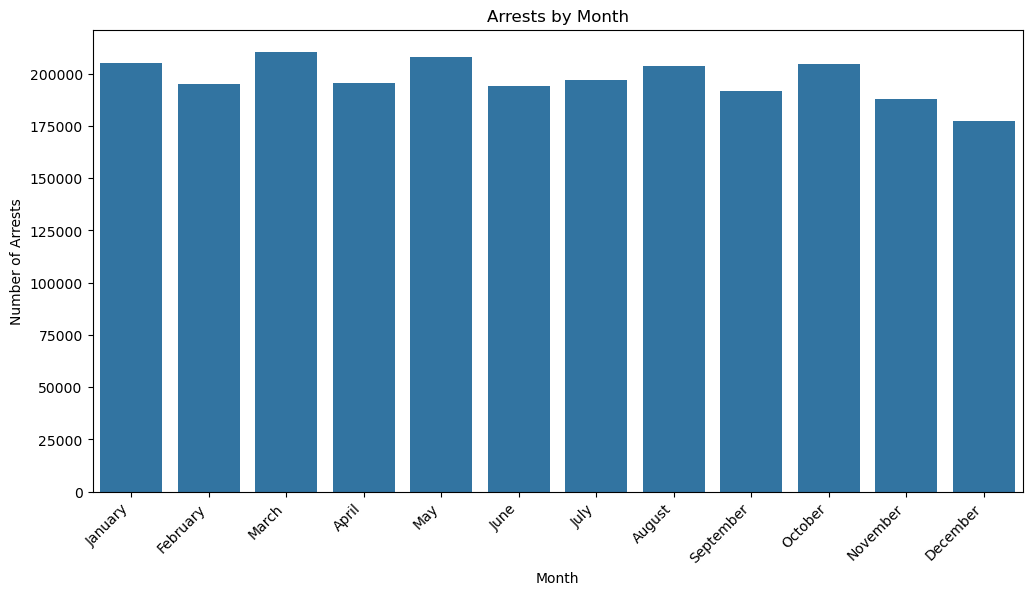

In [16]:
# Arrests by month
import calendar
monthly_arrests = df['ARREST_MONTH'].value_counts().sort_index()
month_names = [calendar.month_name[month] for month in monthly_arrests.index]

plt.figure(figsize=(12, 6))
plt.xticks(rotation=45, ha='right')

sns.barplot(x=month_names, y=monthly_arrests.values)
plt.title('Arrests by Month')
plt.xlabel('Month')
plt.ylabel('Number of Arrests')
plt.show()

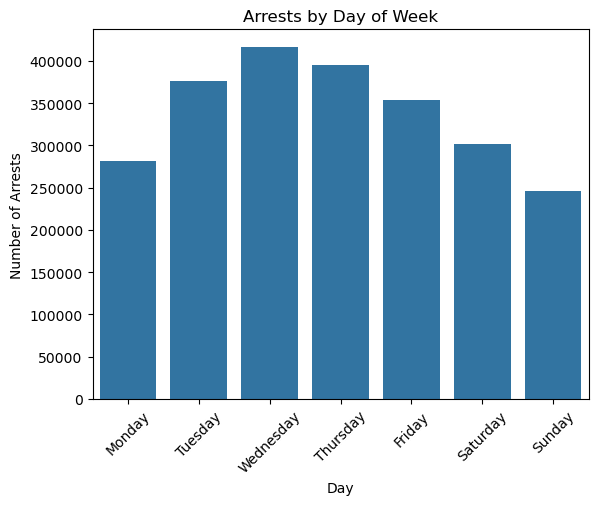

In [17]:
# Arrests by day of week
if 'ARREST_WEEKDAY' in df.columns:
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    day_arrests = df['ARREST_WEEKDAY'].value_counts().reindex(day_order)
    sns.barplot(x=day_arrests.index, y=day_arrests.values)
    plt.title('Arrests by Day of Week')
    plt.xlabel('Day')
    plt.ylabel('Number of Arrests')
    plt.xticks(rotation=45)
plt.show()

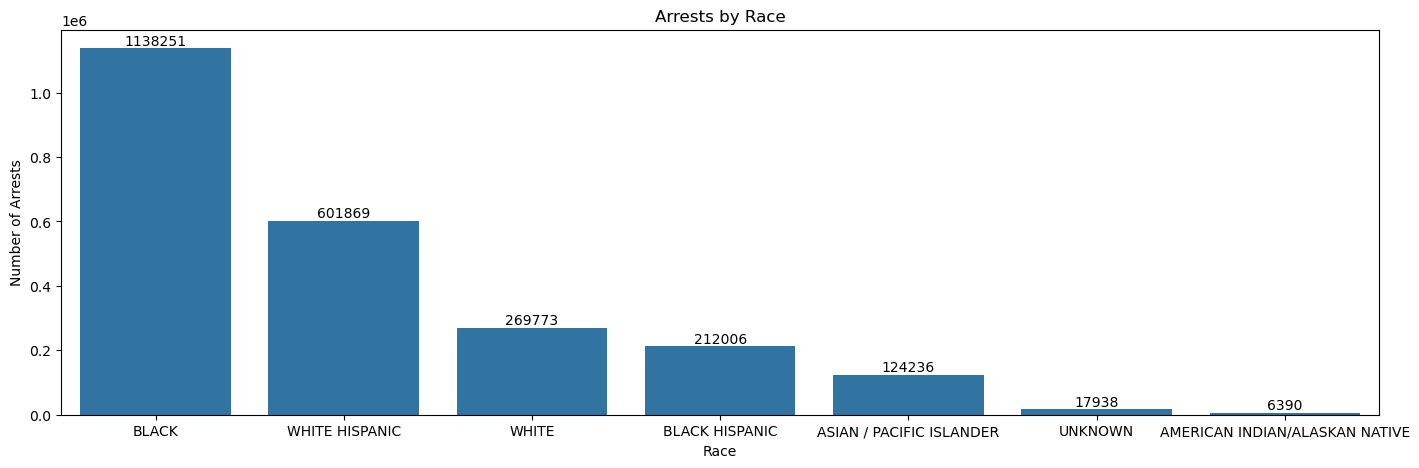

In [18]:
### Arrests by Race:

age_group_counts = df['PERP_RACE'].value_counts()

plt.figure(figsize=(17, 5))
sns.barplot(x=age_group_counts.index, y=age_group_counts.values, legend=False)
plt.title("Arrests by Race")
plt.xlabel("Race")
plt.ylabel("Number of Arrests")
for index, value in enumerate(age_group_counts.values):
    plt.text(index, value, str(value), ha='center', va='bottom')
plt.show()

In [19]:
#Below are Charts separating each year
df['ARREST_YEAR'] = df['ARREST_DATE'].dt.year

In [20]:
df.head()

,ARREST_KEY,ARREST_DATE,PD_DESC,OFNS_DESC,ARREST_BORO,AGE_GROUP,PERP_SEX,PERP_RACE,LATITUDE,LONGITUDE,ARREST_MONTH,ARREST_DAY,ARREST_WEEKDAY,ARREST_YEAR
0,298702124,2024-12-31,"CONTROLLED SUBSTANCE, POSSESSI",DANGEROUS DRUGS,K,25-44,M,BLACK,40.687872,-73.933032,12,31,Tuesday,2024
1,298699274,2024-12-31,"ASSAULT 2,1,UNCLASSIFIED",FELONY ASSAULT,M,25-44,F,BLACK,40.813056,-73.949068,12,31,Tuesday,2024
2,298679856,2024-12-31,"ASSAULT 2,1,UNCLASSIFIED",FELONY ASSAULT,B,25-44,F,WHITE HISPANIC,40.816067,-73.917644,12,31,Tuesday,2024
3,298694773,2024-12-31,CRIMINAL MIS 2 & 3,CRIMINAL MISCHIEF & RELATED OF,B,25-44,M,BLACK,40.822534,-73.906096,12,31,Tuesday,2024
4,298703584,2024-12-31,"CRIMINAL MISCHIEF,UNCLASSIFIED 4",CRIMINAL MISCHIEF & RELATED OF,M,25-44,M,WHITE HISPANIC,40.751978,-73.989915,12,31,Tuesday,2024


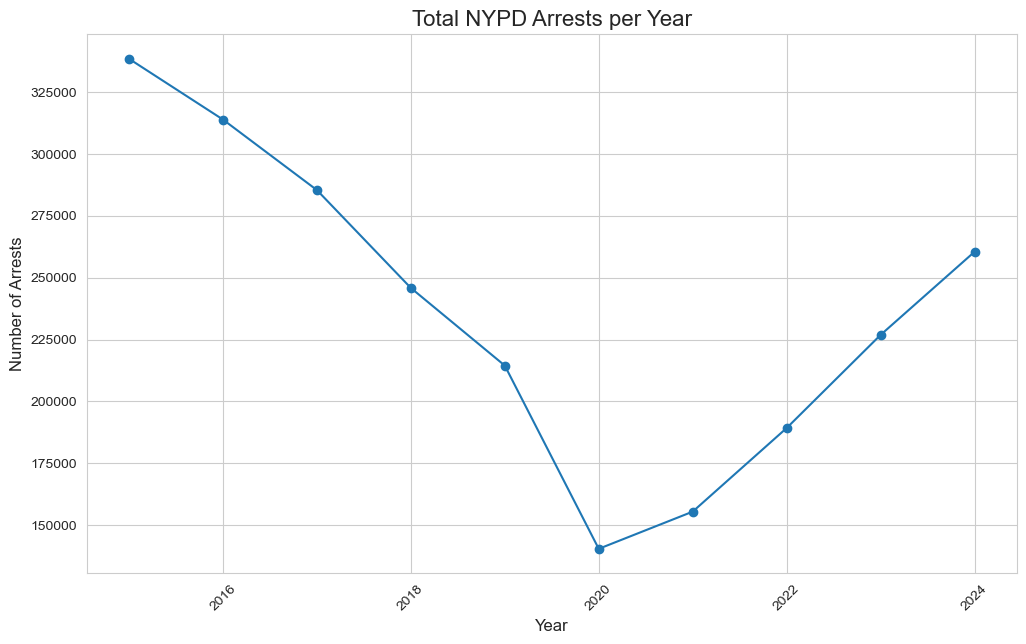

In [22]:
sns.set_style("whitegrid")

yearly_arrests = df['ARREST_YEAR'].value_counts()
yearly_arrests = yearly_arrests.sort_index()

plt.figure(figsize=(12, 7))
yearly_arrests.plot(kind='line', marker='o', linestyle='-')

plt.title('Total NYPD Arrests per Year', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Arrests', fontsize=12)

plt.xticks(rotation=45)

plt.show()